# 03: Exploratory Data Analysis
### Stack Overflow Developer Survey: Curriculum Optimization for High-Yield Tech Stacks

**Name:** Sara AlNajjar  
**Cohort:** General Assembly Data Science, DSBFT2  
**Project:** Project 2: Exploratory Data Analysis


## 1. Imports & Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the cleaned, combined dataset exported by 02_Data_Cleaning.ipynb
df_clean = pd.read_csv('../Data/Cleaned/stack_overflow_cleaned.csv')
df_clean.shape

(9453, 8)

In [3]:
df_clean.head()

,ResponseId,Country,EdLevel,DevType,OrgSize,LanguageHaveWorkedWith,ConvertedCompYearly,SurveyYear
0,390,United States of America,Some college/university study without earning ...,Student,10 to 19 employees,HTML/CSS;JavaScript;Python;SQL;TypeScript,110000.0,2024
1,399,United States of America,Some college/university study without earning ...,"Developer, full-stack","1,000 to 4,999 employees",Bash/Shell (all shells);C#;HTML/CSS;JavaScript...,195000.0,2024
2,429,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Engineer, site reliability",100 to 499 employees,Bash/Shell (all shells);Go;Python;Rust,230000.0,2024
3,432,United States of America,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, full-stack",20 to 99 employees,Bash/Shell (all shells);C#;C++;Go;HTML/CSS;Jav...,85000.0,2024
4,433,United States of America,"Secondary school (e.g. American high school, G...","Developer, full-stack",10 to 19 employees,C#;Go;HTML/CSS;JavaScript;SQL;TypeScript,160000.0,2024


## 2. Multi-select Field Parsing: `LanguageHaveWorkedWith`

This field is stored as a semicolon-delimited string per respondent. Splitting and exploding into long format enables grouping compensation by individual language.

In [4]:
# Split the language field, then explode so each row represents one respondent-language pair
df_clean['LanguageList'] = df_clean['LanguageHaveWorkedWith'].str.split(';')

df_lang = df_clean.explode('LanguageList')
df_lang['LanguageList'] = df_lang['LanguageList'].str.strip()

df_lang[['ResponseId', 'SurveyYear', 'LanguageList', 'ConvertedCompYearly']].head(10)

,ResponseId,SurveyYear,LanguageList,ConvertedCompYearly
0,390,2024,HTML/CSS,110000.0
0,390,2024,JavaScript,110000.0
0,390,2024,Python,110000.0
0,390,2024,SQL,110000.0
0,390,2024,TypeScript,110000.0
1,399,2024,Bash/Shell (all shells),195000.0
1,399,2024,C#,195000.0
1,399,2024,HTML/CSS,195000.0
1,399,2024,JavaScript,195000.0
1,399,2024,PowerShell,195000.0


## 3. EDA: Compensation by Language

Core analysis for the Curriculum Optimization approach, which languages are associated with the highest pay, and which are gaining or losing ground year over year.

### 3a. Median Compensation by Language

In [12]:
# Calculate median compensation per language, along with sample size
lang_comp = (
    df_lang.groupby('LanguageList')['ConvertedCompYearly']
    .agg(['median', 'count'])
    .sort_values('median', ascending=False)
)

# Filter out languages with very few respondents (count < 30) so the ranking isn't distorted by high earners in a niche language
lang_comp_reliable = lang_comp[lang_comp['count'] >= 30]
lang_comp_reliable.head(10)

,median,count
LanguageList,,
Scala,200000.0,277
Erlang,180000.0,145
Elixir,180000.0,303
Solidity,175000.0,33
Clojure,175000.0,99
Ruby,170000.0,890
Go,170000.0,1692
Objective-C,165000.0,126
Prolog,165000.0,46


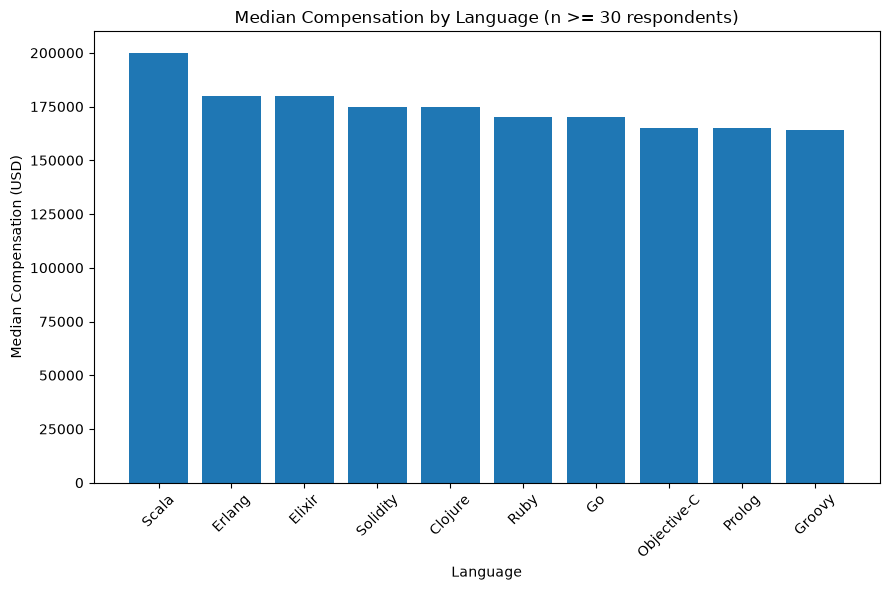

In [15]:
# 3a: Median Compensation by Language
plt.figure(figsize=(9, 6))
plt.bar(lang_comp_reliable.head(10).index, lang_comp_reliable.head(10)['median'])
plt.xlabel('Language')
plt.ylabel('Median Compensation (USD)')
plt.title('Median Compensation by Language (n >= 30 respondents)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Among languages with at least 30 respondents, Scala leads with a median compensation of `$200,000`, followed by Erlang and Elixir at `$180,000`, and Solidity and Clojure at `$175,000`. Ruby and Go round out the top tier at roughly `$170,000`. Most of the highest-paying languages come from small, specialized respondent pools. Solidity (33 respondents) and Clojure (99 respondents) reflect niche expertise rather than a broad market. Ruby (890 respondents) and Go (1,692 respondents) stand out as the only high-paying languages backed by a substantial sample size, making them far more reliable signals of market value.

### 3b. Year-over-Year Compensation Growth by Language

In [16]:
# Pivot median compensation by language and survey year for side-by-side comparison
lang_year_comp = (
    df_lang.groupby(['LanguageList', 'SurveyYear'])['ConvertedCompYearly']
    .median()
    .unstack('SurveyYear')
)

# Percentage change in median compensation from 2024 to 2025
lang_year_comp['pct_change'] = (
    (lang_year_comp[2025] - lang_year_comp[2024]) / lang_year_comp[2024] * 100
)

lang_year_comp.sort_values('pct_change', ascending=False).head(10)

SurveyYear,2024,2025,pct_change
LanguageList,,,
Prolog,140000.0,200000.0,42.857143
Dart,129000.0,160000.0,24.031008
GDScript,119000.0,133000.0,11.764706
HTML/CSS,130000.0,145000.0,11.538462
Go,163000.0,180000.0,10.429448
Swift,150000.0,165000.0,10.000000
Lua,140000.0,153672.5,9.766071
Visual Basic (.Net),110000.0,120000.0,9.090909
MATLAB,120000.0,130000.0,8.333333


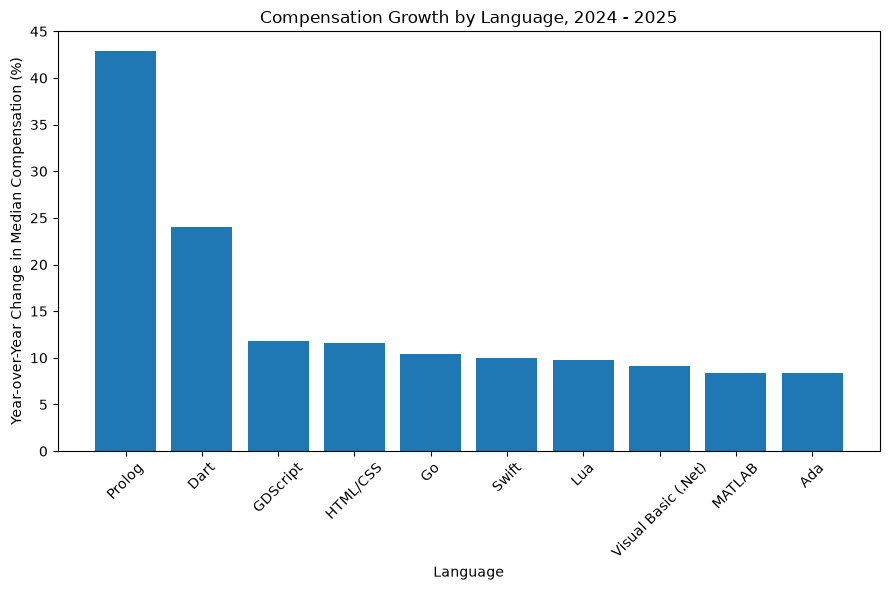

In [17]:
# 3b: Year-over-Year Compensation Growth by Language
top_growth = lang_year_comp.sort_values('pct_change', ascending=False).head(10)

plt.figure(figsize=(9, 6))
plt.bar(top_growth.index, top_growth['pct_change'])
plt.xlabel('Language')
plt.ylabel('Year-over-Year Change in Median Compensation (%)')
plt.title('Compensation Growth by Language, 2024 - 2025')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Prolog shows the sharpest increase at 42.9% (from `$140,000` to `$200,000`), but with a small underlying sample, this is better read as a volatile outlier than a trend. Dart follows at 24.0% growth, and HTML/CSS at 11.5%. The more dependable signal is Go, growing 10.4% year-over-year, a meaningful increase given its already-large adoption base. HTML/CSS is also worth noting: unlike most other languages on this list, it's foundational and beginner-accessible, which matters directly for curriculum planning.

### 3c. Language Popularity vs. Compensation

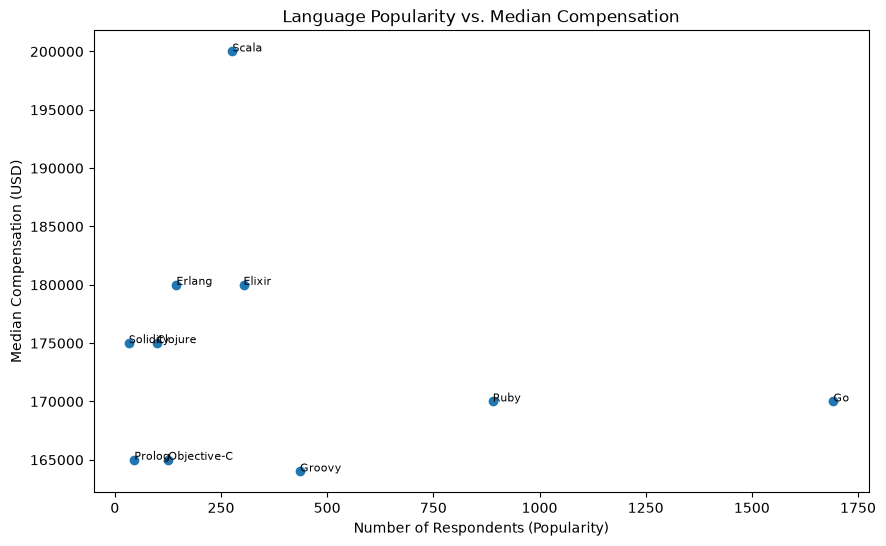

In [7]:
# Plot popularity (respondent count) against median compensation for the top-paying languages, to see whether high pay and high adoption overlap
top_langs = lang_comp_reliable.head(10)

plt.figure(figsize=(10, 6))
plt.scatter(top_langs['count'], top_langs['median'])
for lang, row in top_langs.iterrows():
    plt.annotate(lang, (row['count'], row['median']), fontsize=8)
plt.xlabel('Number of Respondents (Popularity)')
plt.ylabel('Median Compensation (USD)')
plt.title('Language Popularity vs. Median Compensation')
plt.show()

Plotting respondent count against median compensation shows most high-paying languages clustered at low adoption.Scala, Erlang, Elixir, Solidity, Clojure, and Prolog all sit under roughly 300 respondents despite strong pay. Go and Ruby are clear outliers, combining high compensation with far broader adoption (1,692 and 890 respondents respectively).

## 4. Summary of Key Findings

- The highest-paying languages in the dataset, Scala, Erlang, Elixir, Solidity, and Clojure, are dominated by small, specialized respondent pools, meaning their high median pay reflects niche expertise rather than broad market demand.
- Go and Ruby are the only languages that combine strong compensation (top 10 median pay) with a large respondent base, making them the most reliable indicators of real market value among developers.
- Go is the standout language overall, appearing in the top tier for pay, popularity, and year-over-year growth (+10.4%) simultaneously, no other language shows strength across all three measures.
- Prolog and Dart posted the largest year-over-year compensation increases (42.9% and 24.0%), but Prolog's small sample size makes it an unreliable trend indicator.
- HTML/CSS is the only foundational, beginner-accessible language to show meaningful compensation growth (+11.5%), distinguishing it from the more specialized languages on the growth list.

## 5. Conclusions & Recommendations

Go should be the top priority for curriculum investment. It is the only language in the dataset that pairs high compensation with wide market adoption and continued year-over-year growth, making it the lowest-risk, highest-return addition to a bootcamp's core teaching stack. Ruby is the second recommendation, offering the same combination of high pay and broad adoption, though without the same growth signal.

Scala, Erlang, Elixir, Solidity, and Clojure should be considered for an advanced or elective track rather than the core curriculum. Their high pay is real, but their small respondent bases suggest a narrow, specialized job market rather than broad hiring demand, a riskier bet for a curriculum meant to serve a wide range of graduates.

HTML/CSS deserves a specific mention as a foundational skill: it is already a curriculum staple, and this data confirms it continues to grow in value, reinforcing that it should remain a core early-stage module rather than be deprioritized in favor of more advanced languages.

## 6. Areas for Further Research

- This analysis used median compensation as the primary measure of value; incorporating job posting volume or `DevType` breakdowns would clarify whether high-paying languages also correspond to a high number of open roles, not just high individual salaries.
- The year-over-year comparison spans only two survey years (2024–2025); a longer time series would help confirm whether growth trends like Go's are sustained or one-off fluctuations.
- Segmenting compensation by `EdLevel` or years of experience would show whether a language's high pay is achievable early in a career (relevant to bootcamp graduates) or only after years of specialization.
- Expanding beyond `LanguageHaveWorkedWith` to include `LanguageWantToWorkWith` could reveal whether developer interest is shifting toward or away from these high-paying languages, which matters for long-term curriculum relevance.
- This analysis was scoped to US respondents only; comparing against other major tech markets could reveal whether these language trends are US-specific or globally consistent.

## 7. Sources

- [Stack Overflow Developer Survey](https://survey.stackoverflow.co/)